# azurea — Test Notebook

Testing `azurea` matplotlib themes in both **dark** and **light** modes.

Install / upgrade:
```bash
pip install --upgrade azurea
```

In [1]:
import azurea
import matplotlib.pyplot as plt
import numpy as np

print("azurea version:", azurea.__version__)
print("available styles:", azurea.available())

azurea version: 0.2.1
available styles: ['azurea.react_dark', 'azurea.react_light']


In [2]:
# Shared demo data
rng = np.random.default_rng(42)
x = np.linspace(0, 4 * np.pi, 200)
series = {
    "sin(x)":     np.sin(x),
    "cos(x)":     np.cos(x),
    "sin(x)/2":   np.sin(x) / 2,
    "noise":      rng.normal(0, 0.3, x.size).cumsum() / 20,
}

categories = ["A", "B", "C", "D", "E"]
bar_values = rng.integers(20, 100, size=len(categories))
scatter_x = rng.normal(0, 1, 120)
scatter_y = scatter_x * 0.6 + rng.normal(0, 0.5, 120)
hist_data = [rng.normal(loc, 1, 300) for loc in (-2, 0, 2)]

In [3]:
def demo_panel(title):
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    fig.suptitle(title, fontsize=15, fontweight="bold")

    ax = axes[0, 0]
    for name, y in series.items():
        ax.plot(x, y, label=name, linewidth=2)
    ax.set_title("Line plot")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.legend(loc="upper right", fontsize=8)

    ax = axes[0, 1]
    colors = azurea.custom_colors[:len(categories)]
    ax.bar(categories, bar_values, color=colors)
    ax.set_title("Bar chart")
    ax.set_ylabel("count")

    ax = axes[1, 0]
    ax.scatter(scatter_x, scatter_y, alpha=0.7, s=40)
    ax.set_title("Scatter plot")
    ax.set_xlabel("x"); ax.set_ylabel("y")

    ax = axes[1, 1]
    ax.hist(hist_data, bins=25, stacked=True,
            label=[f"g{i+1}" for i in range(len(hist_data))])
    ax.set_title("Histogram")
    ax.set_xlabel("value"); ax.set_ylabel("freq")
    ax.legend(fontsize=8)

    fig.tight_layout()
    return fig

## Dark mode — `azurea.react_dark`

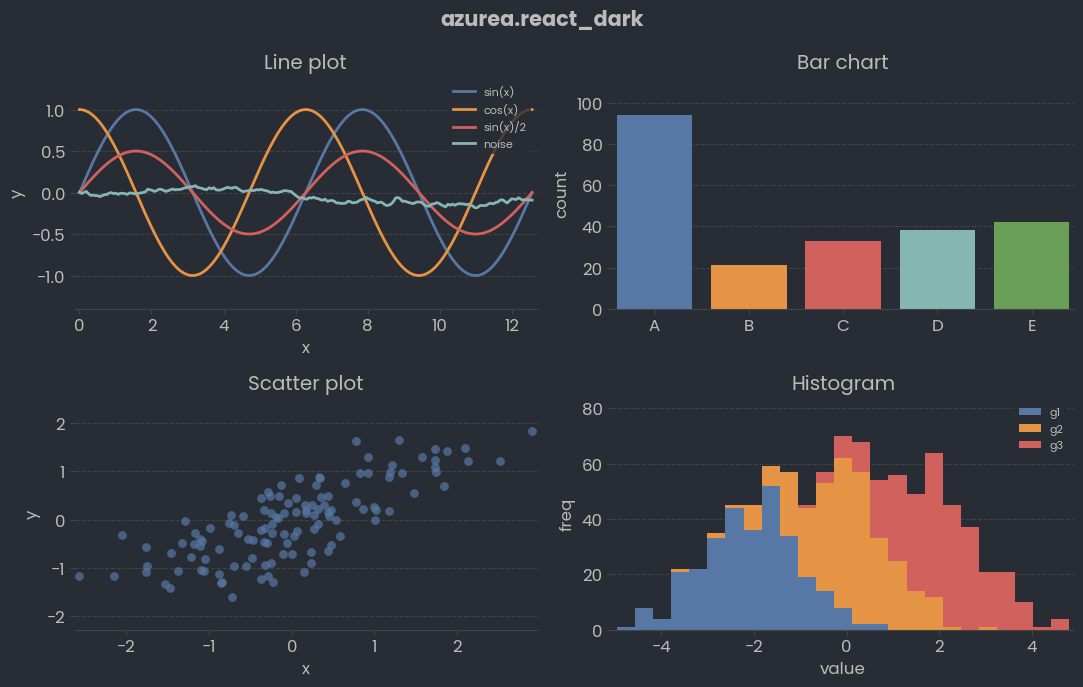

In [4]:
azurea.use("react_dark")
demo_panel("azurea.react_dark")
plt.show()

## Light mode — `azurea.react_light`

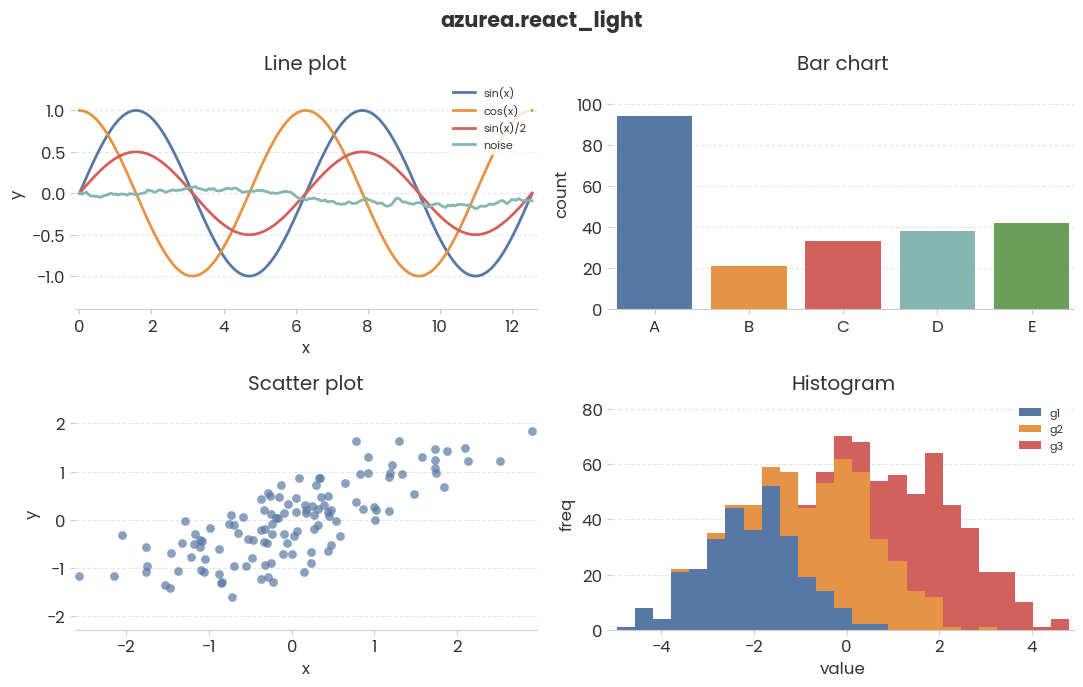

In [5]:
azurea.use("react_light")
demo_panel("azurea.react_light")
plt.show()

## Color palette — `azurea.custom_colors`

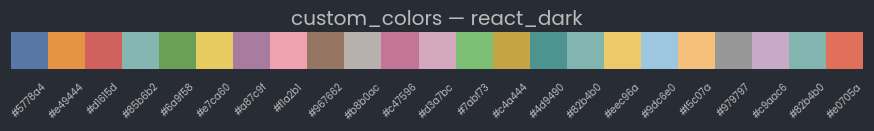

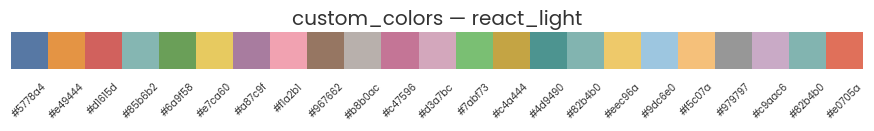

In [6]:
for style in ("react_dark", "react_light"):
    azurea.use(style)
    fig, ax = plt.subplots(figsize=(11, 2))
    for i, c in enumerate(azurea.custom_colors):
        ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=c))
        ax.text(i + 0.5, -0.3, c, ha="center", va="top", fontsize=7, rotation=45)
    ax.set_xlim(0, len(azurea.custom_colors))
    ax.set_ylim(-1, 1)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(f"custom_colors — {style}")
    plt.show()